# **Import Libraries**

In [ ]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

In [42]:
from utils.experiment_separator import (
    separate_experiments,
    get_experiment_summary,
    print_experiment_report,
    get_experiments,
)

# **Import Dataset**

In [43]:
PATH = "../data/data.csv"
df_raw = pd.read_csv(PATH)

# **Rename Columns**

In [44]:
df = df_raw.copy()
df.columns = ['density', 'cutting_speed', 'feed_rate', 'depth', 'axial_force', 'cutting_force']

In [45]:
TARGET = 'axial_force'
FEATURES = ['density', 'cutting_speed', 'feed_rate', 'depth']

# **Separate Experiments**

In [46]:
df = separate_experiments(df)
print_experiment_report(df)
experiments = get_experiments(df)

Total unique combinations : 72
Experiment count range    : 2 – 3
Total experiments         : 198

── Experiments per combination ──
 density  cutting_speed  feed_rate  experiment_count
      10             10         10                 3
      10             10         15                 3
      10             10         20                 3
      10             16         10                 3
      10             16         15                 3
      10             16         20                 3
      10             25         10                 3
      10             25         15                 3
      10             25         20                 3
      10             40         10                 3
      10             40         15                 3
      10             40         20                 3
      10             63         10                 3
      10             63         15                 3
      10             63         20                 3
      10            

# **Preprocessing Pipeline**

## Data Cleaning

In [47]:
def apply_remove_null(df: pd.DataFrame) -> pd.DataFrame:
    return df.dropna()

## Data Scaling

In [48]:
def apply_scaling(df: pd.DataFrame, scaler: MinMaxScaler, fit: bool = False) -> pd.DataFrame:
    cols = FEATURES + [TARGET]
    if fit:
        df[cols] = scaler.fit_transform(df[cols])
    else:
        df[cols] = scaler.transform(df[cols])
    return df

## Feature Engineering

In [49]:
def apply_add_feature(df: pd.DataFrame) -> pd.DataFrame:
    return df

## Data Pipeline

In [ ]:
class Pipeline:
    def __init__(self):
        self.scaler = MinMaxScaler()

    def fit_transform(self, df: pd.DataFrame) -> pd.DataFrame:
        temp = df.copy()
        temp = apply_remove_null(temp)
        temp = apply_scaling(temp, self.scaler, fit=True)
        temp = apply_add_feature(temp)
        return temp

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        temp = df.copy()
        temp = apply_remove_null(temp)
        temp = apply_scaling(temp, self.scaler, fit=False)
        temp = apply_add_feature(temp)
        return temp

# **Train/Val Split**

In [ ]:
exp_keys = list(experiments.keys())
n_total = len(exp_keys)
n_train = int(n_total * 0.8)
n_val   = n_total - n_train

train_keys = exp_keys[:n_train]
val_keys   = exp_keys[n_train:]

print(f"\nTotal experiments : {n_total}")
print(f"Train experiments : {len(train_keys)}")
print(f"Val experiments   : {len(val_keys)}")

def experiments_to_tensor(keys, experiments, pipeline, fit=False):
    """Concatenates experiments into X, y tensors."""
    X_list, y_list = [], []
    ref_df = pd.concat([experiments[k] for k in keys], ignore_index=True)

    if fit:
        processed = pipeline.fit_transform(ref_df)
    else:
        processed = pipeline.transform(ref_df)

    X_list = processed[FEATURES].values
    y_list = processed[TARGET].values

    X = torch.tensor(X_list, dtype=torch.float32).unsqueeze(1)
    y = torch.tensor(y_list, dtype=torch.float32).unsqueeze(1)
    return X, y



Total experiments : 198
Train experiments : 158
Val experiments   : 40


# **Modeling**

In [52]:
INPUT_SIZE  = len(FEATURES)
OUTPUT_SIZE = 1

## Training Loop

In [53]:
def train(model, model_name: str, experiments: dict, train_keys: list, val_keys: list):
    pipeline  = Pipeline()
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=model.lr)

    X_train, y_train = experiments_to_tensor(train_keys, experiments, pipeline, fit=True)
    X_val,   y_val   = experiments_to_tensor(val_keys,   experiments, pipeline, fit=False)

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=model.batch_size, shuffle=True)

    print(f"\n── Training {model_name} ──")
    for epoch in range(model.epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = criterion(val_pred, y_val).item()

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}/{model.epochs} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss:.4f}")

    return model

## Validation

In [54]:
def plot_results(model, model_name, X_val, y_val):
    model.eval()
    with torch.no_grad():
        preds = model(X_val).squeeze().numpy()
    actuals = y_val.squeeze().numpy()

    plt.figure(figsize=(12, 4))
    plt.plot(actuals, label='Actual',    color='steelblue')
    plt.plot(preds,   label='Predicted', color='tomato', linestyle='--')
    plt.title(f"{model_name} — Actual vs Predicted (axial_force)")
    plt.xlabel("Sample")
    plt.ylabel("axial_force (scaled)")
    plt.legend()
    plt.tight_layout()
    plt.show()

pipeline_final = Pipeline()
_, _ = experiments_to_tensor(train_keys, experiments, pipeline_final, fit=True)
X_val_t, y_val_t = experiments_to_tensor(val_keys, experiments, pipeline_final, fit=False)

## LSTM

In [57]:
class LSTM(nn.Module):
    hidden_size = 64
    num_layers  = 2
    epochs      = 10
    batch_size  = 32
    lr          = 1e-3

    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(INPUT_SIZE, self.hidden_size, self.num_layers, batch_first=True)
        self.fc   = nn.Linear(self.hidden_size, OUTPUT_SIZE)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


── Training LSTM ──
  Epoch 10/10 | Train Loss: 0.0001 | Val Loss: 0.0273


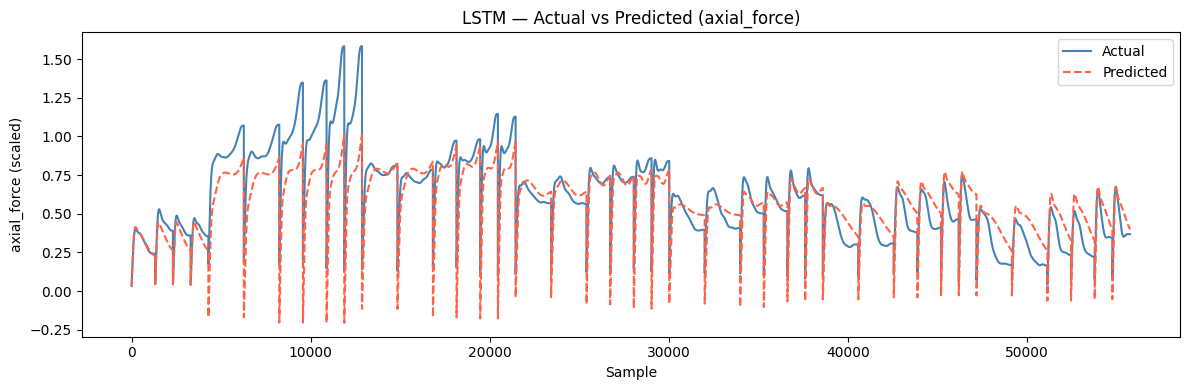

In [58]:
lstm_model = train(LSTM(), "LSTM", experiments, train_keys, val_keys)
plot_results(lstm_model, "LSTM", X_val_t, y_val_t)

## GRU

In [59]:
class GRU(nn.Module):
    hidden_size = 64
    num_layers  = 2
    epochs      = 10
    batch_size  = 32
    lr          = 1e-3

    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(INPUT_SIZE, self.hidden_size, self.num_layers, batch_first=True)
        self.fc  = nn.Linear(self.hidden_size, OUTPUT_SIZE)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])


── Training GRU ──
  Epoch 10/10 | Train Loss: 0.0001 | Val Loss: 0.0337


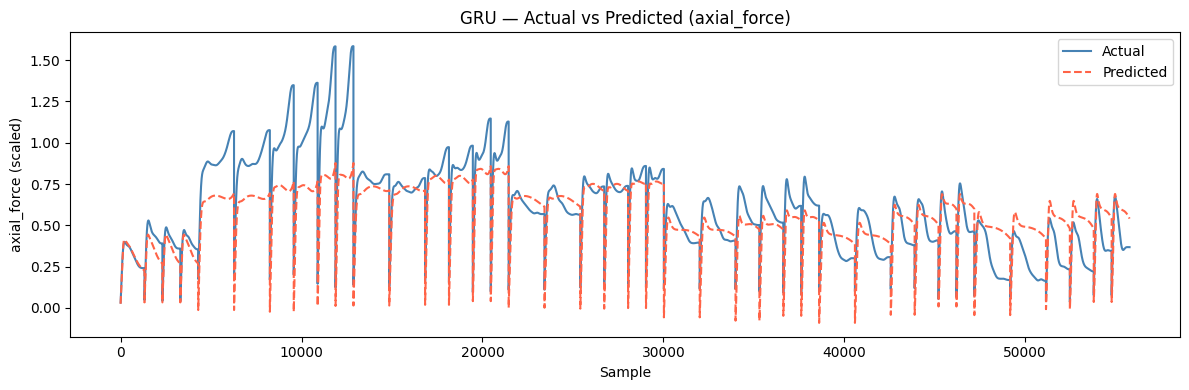

In [60]:
gru_model = train(GRU(), "GRU", experiments, train_keys, val_keys)
plot_results(gru_model, "GRU", X_val_t, y_val_t)

## RNN

In [61]:
class RNN(nn.Module):
    hidden_size = 64
    num_layers  = 2
    epochs      = 10
    batch_size  = 32
    lr          = 1e-3

    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(INPUT_SIZE, self.hidden_size, self.num_layers, batch_first=True)
        self.fc  = nn.Linear(self.hidden_size, OUTPUT_SIZE)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])


── Training RNN ──
  Epoch 10/10 | Train Loss: 0.0002 | Val Loss: 0.0594


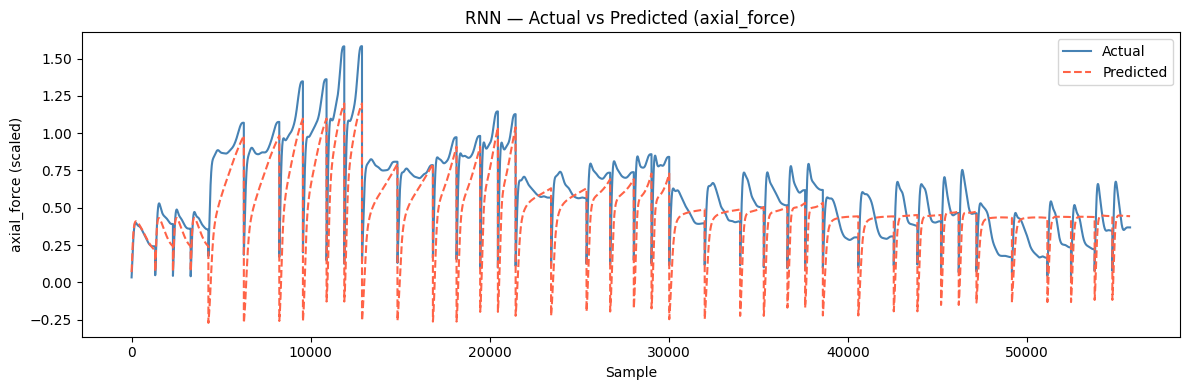

In [62]:
rnn_model = train(RNN(), "RNN", experiments, train_keys, val_keys)
plot_results(rnn_model, "RNN", X_val_t, y_val_t)

# **Validation**

In [71]:
def evaluate(model, model_name, X_val, y_val, pipeline):
    model.eval()
    with torch.no_grad():
        preds   = model(X_val).squeeze().numpy()
    actuals = y_val.squeeze().numpy()

    n = len(preds)
    n_cols = len(FEATURES) + 1

    dummy_preds = np.zeros((n, n_cols))
    dummy_preds[:, -1] = preds
    preds_orig = pipeline.scaler.inverse_transform(dummy_preds)[:, -1]

    dummy_actuals = np.zeros((n, n_cols))
    dummy_actuals[:, -1] = actuals
    actuals_orig = pipeline.scaler.inverse_transform(dummy_actuals)[:, -1]

    mae  = mean_absolute_error(actuals_orig, preds_orig)
    mse  = mean_squared_error(actuals_orig, preds_orig)
    rmse = np.sqrt(mse)
    std  = np.std(actuals_orig)

    mae_pct  = (mae  / std) * 100
    rmse_pct = (rmse / std) * 100

    print(f"── {model_name} ──")
    print(f"  MAE  : {mae:.4f}  ({mae_pct:.2f}% of std)")
    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {rmse:.4f}  ({rmse_pct:.2f}% of std)")
    print(f"  STD  : {std:.4f}")
    print()

evaluate(lstm_model, "LSTM", X_val_t, y_val_t, pipeline_final)
evaluate(gru_model,  "GRU",  X_val_t, y_val_t, pipeline_final)
evaluate(rnn_model,  "RNN",  X_val_t, y_val_t, pipeline_final)

── LSTM ──
  MAE  : 22.7366  (44.55% of std)
  MSE  : 966.8337
  RMSE : 31.0939  (60.92% of std)
  STD  : 51.0404

── GRU ──
  MAE  : 25.6927  (50.34% of std)
  MSE  : 1193.8587
  RMSE : 34.5523  (67.70% of std)
  STD  : 51.0404

── RNN ──
  MAE  : 35.5997  (69.75% of std)
  MSE  : 2102.5791
  RMSE : 45.8539  (89.84% of std)
  STD  : 51.0404

